# Does the environmental signal attenuate with causal distance?

**This notebook is exploratory, not inferential.** No p-values, no significance tests, no PERMANOVA. This notebook generates the hypothesis that Phase 4 would test properly, it does not test it here.

Environmental discrimination of a cultural trait declines as the trait moves away from direct material constraint. Four tiers, declared here and not revised after seeing output:

| Tier | Trait | EA code |
|---|---|---|
| 1 -- Direct material constraint | Dominant subsistence | EA042 |
| 2 -- Settlement form | Settlement pattern | EA030 |
| 2 -- Settlement form | Mean community size | EA031 (caveat: only 611 of 1,291 EA societies have this coded at all -- discount this trait's result relative to the other five) |
| 3 -- Social organization | Jurisdictional hierarchy beyond local community | EA033 |
| 3 -- Social organization | Class differentiation (primary) | EA066 |
| 4 -- Cosmology | High gods | EA034 |

**A non-monotonic result is a finding, not a failure.** Tier assignment is theoretical, fixed in advance; no trait is added, dropped, or moved after its spread is computed.

All five environmental dimensions (aridity, temperature, seasonality, ruggedness, landform) are computed for every trait, not aridity alone -- aridity-only would be circular, since aridity is what discriminated in WO1.

**Rules fixed before any output is computed:**
- **n-floor = 20.** A trait category with fewer than 20 basin-joined-and-coded societies is dropped before its spread is computed, not after. (Settled with Karl 2026-08-09 against the actual category counts -- EA030's "Impermanent" (n=15) and EA031's "1000-5000" (n=17) are the only categories this drops across all six traits.)
- **Headline measure = max spread across the five dimensions**, not mean. Rationale: the claim under test is "environment discriminates this trait," for which one dimension doing the work is sufficient. Mean spread reported alongside as a secondary column, never substituted for max after the fact.
- **Continental spread is a single fixed baseline, not recomputed per trait** (Decision A, confirmed with Karl 2026-08-09 -- full reasoning and the rejected alternative are logged at the bottom of this notebook, not just asserted here). Continent stands in as a pure culture-history grouping with no material link to environment by construction; its own environmental spread (same method: range across the 6 continents' group-mean percentiles) is computed once and reused as the denominator for every trait's ratio.

WO: `docs/edop/docsv4/wo2_causal-distance.md`. Depends on WO1 machinery (`notebooks/edop/docsv4/wo1_high-gods-subsistence-environment.ipynb`).

In [1]:
# Cell 1
%matplotlib inline
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.shared import db_utils
from scripts.shared.db_utils import db_connect
from scripts.cdop.distance_core import variable_percentiles, VARIABLES

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT = ROOT / 'output' / 'edop' / 'docsv4'
OUT.mkdir(parents=True, exist_ok=True)
SUBSTRATE_PATH = ROOT / 'output' / 'cdop' / 'wo8c_substrate.parquet'

conn = db_connect()
substrate = pd.read_parquet(SUBSTRATE_PATH)
print(f"connected; substrate: {len(substrate)} basin-joined EA societies, {len(substrate.columns)} columns")

connected; substrate: 1133 basin-joined EA societies, 35 columns


## Data assembly

`wo8c_substrate.parquet` only carries `ea042_subsistence` and `ea034_religion` (WO1's two traits) -- EA030/EA031/EA033/EA066 aren't in it. Pulled fresh and merged onto the substrate by `soc_id`, same join pattern as WO1.

In [2]:
# Cell 2
NEW_TRAITS = {
    'ea030_settlement':      'EA030',
    'ea031_community_size':  'EA031',
    'ea033_juris_hierarchy': 'EA033',
    'ea066_class_strat':     'EA066',
}
for col, var in NEW_TRAITS.items():
    codes = pd.read_sql(f"""
        SELECT s.id AS soc_id, c.name AS {col}
        FROM dplace.societies s
        JOIN dplace.data d ON d.soc_id = s.id AND d.var_id = '{var}'
        JOIN dplace.codes c ON c.id = d.code_id AND c.name NOT IN ('Missing data', '')
        WHERE s.contribution_id = 'dplace-dataset-ea'
    """, conn)
    substrate = substrate.merge(codes, on='soc_id', how='left')

counts = ", ".join(f"{col}={substrate[col].notna().sum()}" for col in NEW_TRAITS)
print(f"Merged onto the {len(substrate)}-row basin-joined substrate. Coded counts "
      f"(basin-joined only, before the n>=20 category floor): {counts}")

Merged onto the 1133-row basin-joined substrate. Coded counts (basin-joined only, before the n>=20 category floor): ea030_settlement=1044, ea031_community_size=539, ea033_juris_hierarchy=1012, ea066_class_strat=970


In [3]:
# Cell 3
continent_df = pd.read_sql("""
    SELECT s.id AS soc_id, a.continent
    FROM dplace.societies s
    LEFT JOIN gaz.admin0 a
        ON ST_Contains(a.geom, ST_SetSRID(ST_MakePoint(s.longitude, s.latitude), 4326))
    WHERE s.contribution_id = 'dplace-dataset-ea'
""", conn)
substrate = substrate.merge(continent_df, on='soc_id', how='left')
print(f"Continent merged; {substrate['continent'].notna().sum()} of {len(substrate)} "
      f"basin-joined societies matched to a continent polygon.")

Continent merged; 1127 of 1133 basin-joined societies matched to a continent polygon.


## Computation machinery

One function pair, reused for all six traits *and* for the continental baseline (`trait_col='continent'` is just another category column as far as this code is concerned -- that symmetry is what makes Decision A a fair comparison rather than a special case). Per category: group-mean percentile (WO1's `variable_percentiles()`) plus member-level interquartile spread (WO1's dispersion fix, carried forward per WO2 §6's own hazard list). Categories below the n-floor are dropped and reported, not silently discarded.

In [4]:
# Cell 4
VAR_KEYS = list(VARIABLES.keys())  # aridity, temperature, seasonality, ruggedness, landform
N_FLOOR = 20

substrate_pct = substrate.copy()
if 'ari_log' not in substrate_pct.columns and 'ari_ix_sav' in substrate_pct.columns:
    substrate_pct['ari_log'] = np.log1p(substrate_pct['ari_ix_sav'])  # matches variable_percentiles()'s own derivation
for k in VAR_KEYS:
    col = VARIABLES[k]['column']
    substrate_pct[f'{k}__pct'] = substrate_pct[col].rank(pct=True) * 100

def category_profile(trait_col, min_n=N_FLOOR):
    """Per-category group-mean percentile + member IQR on each dimension. Categories with
    n < min_n are dropped (declared floor) and returned separately, not silently discarded."""
    counts = substrate_pct[trait_col].value_counts()
    keep = counts[counts >= min_n].index.tolist()
    rows = []
    for cat in keep:
        res = variable_percentiles(substrate, trait_col=trait_col, value=cat)
        mask = substrate_pct[trait_col] == cat
        row = {'category': cat, 'n': int(counts[cat])}
        for k in VAR_KEYS:
            row[k] = res['variables'].get(k, {}).get('percentile', np.nan)
            member_pct = substrate_pct.loc[mask, f'{k}__pct'].dropna()
            row[f'{k}__p25'] = member_pct.quantile(0.25) if len(member_pct) else np.nan
            row[f'{k}__p75'] = member_pct.quantile(0.75) if len(member_pct) else np.nan
        rows.append(row)
    dropped = counts[counts < min_n]
    return pd.DataFrame(rows).set_index('category'), dropped

def trait_spread(trait_col, min_n=N_FLOOR):
    """Range across kept categories' group-mean percentile, per dimension -- the discrimination measure."""
    prof, dropped = category_profile(trait_col, min_n)
    if len(prof) >= 2:
        spread = {k: float(prof[k].max() - prof[k].min()) for k in VAR_KEYS}
    else:
        spread = {k: np.nan for k in VAR_KEYS}
    return spread, prof, dropped

print(f"machinery defined: category_profile() / trait_spread(), n-floor={N_FLOOR}.")

machinery defined: category_profile() / trait_spread(), n-floor=20.


## The continental baseline (Decision A)

Computed once, reused as the fixed denominator for every trait's ratio below.

In [5]:
# Cell 5
continental_spread, continental_profile, continental_dropped = trait_spread('continent')
print(pd.Series(continental_spread, name='continental_spread').round(1).to_string())

aridity        52.6
temperature    51.2
seasonality    61.2
ruggedness     22.1
landform       13.2


## Per-trait spread and ratio-to-continent, all six traits

`max_ratio`/`mean_ratio` compare each trait's own spread to the continental baseline **on the same dimension(s)** -- not to continent's own max, which could be a different dimension entirely.

In [6]:
# Cell 6
TIER_TRAITS = [
    (1, 'ea042_subsistence',     'EA042 Dominant subsistence'),
    (2, 'ea030_settlement',      'EA030 Settlement pattern'),
    (2, 'ea031_community_size',  'EA031 Mean community size'),
    (3, 'ea033_juris_hierarchy', 'EA033 Jurisdictional hierarchy'),
    (3, 'ea066_class_strat',     'EA066 Class differentiation'),
    (4, 'ea034_religion',        'EA034 High gods'),
]

results = []
category_profiles = {}
for tier, col, label in TIER_TRAITS:
    spread, prof, dropped = trait_spread(col)
    category_profiles[label] = (prof, dropped)
    max_dim = max(spread, key=spread.get)
    row = {
        'tier': tier, 'trait': label,
        'n_categories_kept': len(prof), 'n_categories_dropped': len(dropped),
        'max_dim': max_dim, 'max_spread': spread[max_dim],
        'max_ratio': spread[max_dim] / continental_spread[max_dim] if continental_spread[max_dim] else np.nan,
        'mean_spread': float(np.mean(list(spread.values()))),
        'mean_ratio': float(np.mean([spread[k] / continental_spread[k] for k in VAR_KEYS if continental_spread[k]])),
    }
    for k in VAR_KEYS:
        row[f'{k}_spread'] = spread[k]
    results.append(row)

results_df = pd.DataFrame(results)
print(results_df[['tier', 'trait', 'n_categories_kept', 'n_categories_dropped',
                   'max_dim', 'max_spread', 'max_ratio', 'mean_spread', 'mean_ratio']]
      .round(2).to_string(index=False))

 tier                          trait  n_categories_kept  n_categories_dropped     max_dim  max_spread  max_ratio  mean_spread  mean_ratio
    1     EA042 Dominant subsistence                  7                     0     aridity       67.78       1.29        40.42        1.06
    2       EA030 Settlement pattern                  7                     1 seasonality       38.57       0.63        25.54        0.67
    2      EA031 Mean community size                  7                     1     aridity       21.09       0.40        16.63        0.52
    3 EA033 Jurisdictional hierarchy                  5                     0     aridity       25.33       0.48        17.91        0.47
    3    EA066 Class differentiation                  5                     0     aridity       38.22       0.73        17.31        0.45
    4                EA034 High gods                  4                     0     aridity       35.75       0.68        14.59        0.39


**Reading:** mixed. On `mean_ratio` the prediction holds cleanly: Tier 1 (1.06) > Tier 2 (0.67, 0.52) > Tier 3 (0.47, 0.45) > Tier 4 (0.39), a clean monotonic decline. On `max_ratio` it does not: Tier 3's EA066 (0.73) exceeds Tier 2's EA030 (0.63), and Tier 4's EA034 (0.68) exceeds Tier 3's EA033 (0.48) and sits close behind Tier 2's EA030 -- High Gods, theoretically the most removed from material constraint, is *not* the least environmentally discriminated trait on this measure. Both EA034 and EA066's max dimension is aridity, same as WO1's own finding; EA034's aridity spread here is almost certainly still carrying the same Pastoralism/Active-supporting-morality signal WO1 could not separate from an Islamic-contact-zone confound, not new evidence of a direct cosmology-environment link. EA031 (thin coded base, flagged for discount) has the lowest ratios of any trait on both measures -- consistent with "weaker signal," though its low n makes that as much a data-quality artifact as a real finding.

## Dimensional specialization

Full per-dimension spread, all six traits -- does each tier peak on a different dimension (seasonality for settlement, ruggedness for jurisdictional hierarchy, per the WO's own prior), or does one dimension (aridity, most likely, per WO1) dominate everywhere regardless of trait?

In [7]:
# Cell 7
detail_cols = ['tier', 'trait'] + [f'{k}_spread' for k in VAR_KEYS]
print(results_df[detail_cols].round(1).to_string(index=False))

 tier                          trait  aridity_spread  temperature_spread  seasonality_spread  ruggedness_spread  landform_spread
    1     EA042 Dominant subsistence            67.8                45.6                49.1               21.9             17.7
    2       EA030 Settlement pattern            34.1                30.3                38.6               13.6             11.2
    2      EA031 Mean community size            21.1                20.8                16.9               11.6             12.8
    3 EA033 Jurisdictional hierarchy            25.3                21.7                22.9               13.0              6.6
    3    EA066 Class differentiation            38.2                18.7                12.0               12.0              5.6
    4                EA034 High gods            35.7                 9.1                13.2                8.5              6.5


**Reading:** aridity dominates almost everywhere, not just where the WO's prior predicted it. 5 of 6 traits (EA042, EA031, EA033, EA066, EA034) peak on aridity, including EA033 (jurisdictional hierarchy), where ruggedness was the theoretical prediction -- ruggedness is actually one of EA033's *smallest* values (13.0). EA030 (settlement pattern) is the one real confirmation, peaking on seasonality (38.6) essentially as predicted, though aridity is a close second (34.1). Landform is the smallest value for every trait without exception -- it never drives a result. The dominance of aridity specifically is itself a flag, not just a finding: continent's own baseline aridity spread (52.6, Cell 5) is one of the two largest of the five baseline dimensions, so aridity's apparent power to discriminate these traits may substantially be riding on the same continental/geographic clustering already implicated as a confound for EA034 in WO1 and here, not five independent trait-specific environmental effects.

## Primary output: tier-ordered spread vs. the continental baseline

One figure, per WO2 §5. Traits ordered by declared tier (1 at top). Environmental spread (max dimension) plotted against the continental baseline **on that same dimension** for each trait, so the two series are always an apples-to-apples comparison, never continent's own unrelated max. If the prediction holds, the environmental series declines down the tiers while the continental series (by construction, closer to flat -- it's the same six-continent computation every time, just read off a different dimension per row) does not.

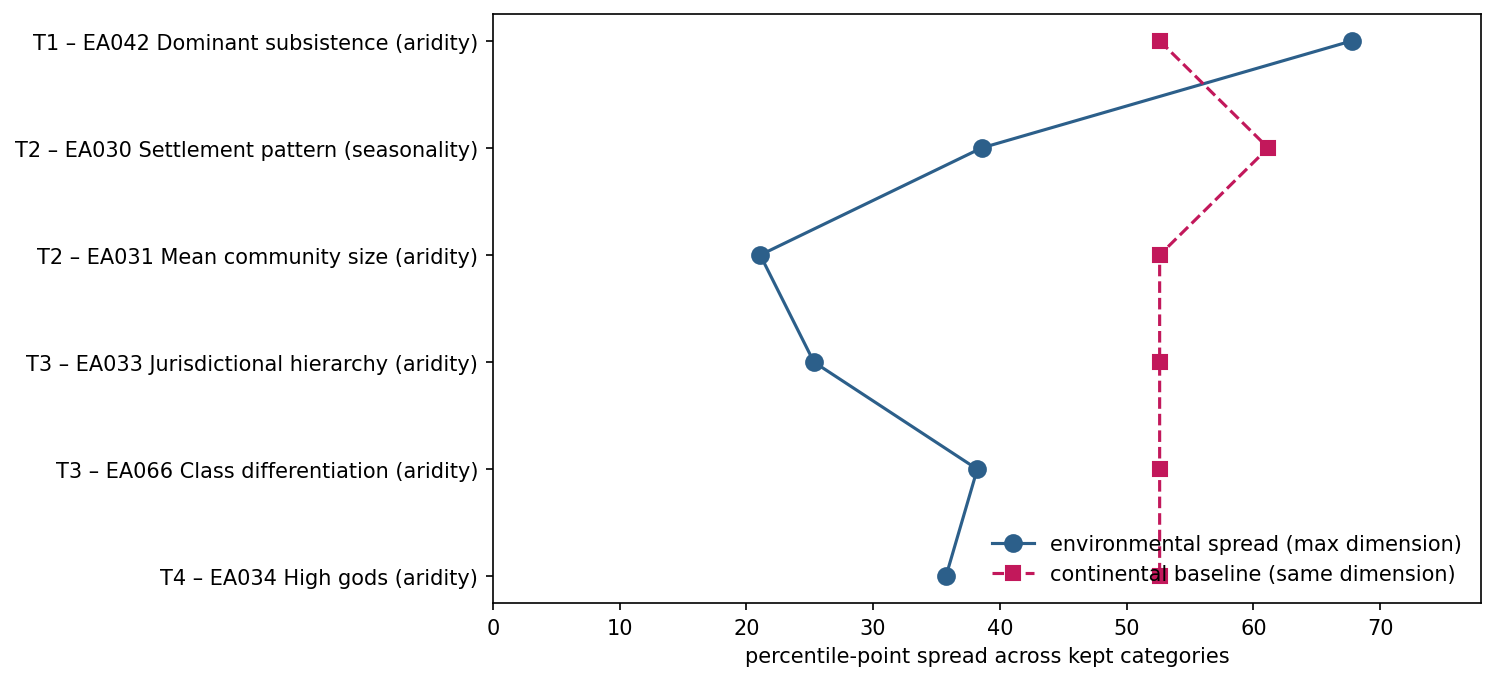

In [8]:
# Cell 8
print("drawing tier x environmental/continental spread figure...")
order = results_df.sort_values('tier', kind='stable').reset_index(drop=True)
cont_vals = [continental_spread[d] for d in order['max_dim']]

fig, ax = plt.subplots(figsize=(8.5, 0.6 * len(order) + 1.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y = np.arange(len(order))[::-1]  # tier 1 at top
ax.plot(order['max_spread'], y, 'o-', color='#2c5f8a', label='environmental spread (max dimension)',
        markersize=8, zorder=3)
ax.plot(cont_vals, y, 's--', color='#c2185b', label='continental baseline (same dimension)',
        markersize=7, zorder=3)

labels = [f"T{t} – {tr} ({d})" for t, tr, d in zip(order['tier'], order['trait'], order['max_dim'])]
ax.set_yticks(y)
ax.set_yticklabels(labels, color='black')
ax.set_xlabel('percentile-point spread across kept categories', color='black')
ax.set_xlim(0, max(order['max_spread'].max(), max(cont_vals)) * 1.15)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
ax.legend(frameon=False, labelcolor='black', loc='lower right')

outpath = OUT / 'wo2_tier_spread.png'
fig.savefig(outpath, facecolor='white', dpi=150, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image as IPImage
display(IPImage(str(outpath)))

**Reading:** the clean part of the figure is Tier 1 vs. everything else: EA042 is the *only* trait whose environmental spread (blue dot) sits to the right of its continental baseline (pink square) -- every other trait, tiers 2 through 4, has less raw spread than continent alone already produces on that same dimension. That divide is real and visually obvious. What doesn't hold is the fine ordering within tiers 2-4: EA030's continental baseline (61.2, seasonality) is the highest pink square on the whole chart, pulling its blue dot furthest below its own baseline even though EA030's raw spread (38.6) is comparable to EA066's (38.2) further down; EA034 (tier 4) sits at a similar distance below its baseline as EA033 (tier 3), not further.

## Conclusions

**Verdict: partially confirmed.** The prediction holds at its coarsest grain -- subsistence (tier 1) is categorically different from every other trait tested, the only one that discriminates environment *beyond* what pure geography/continental clustering already would. That's a real, clean result. It does not hold at finer grain: the tier-by-tier ordering among tiers 2, 3, and 4 is not monotonic on the headline `max_ratio` measure (Cell 6), and the dimensional-specialization check (Cell 7) suggests why -- 5 of the 6 traits, across all four tiers, peak on the same single dimension (aridity), and aridity's own continental baseline is one of the two largest of the five. That pattern looks less like four tiers each responding to environment in proportion to material distance, and more like one dominant, likely continent-confounded dimension (aridity) recurring across nearly every trait regardless of tier, plus one genuine, distinct confirmation (EA030/settlement pattern discriminating specifically on seasonality, matching the WO's own prior). EA034's tier-4 result in particular should be read together with WO1: it is most plausibly the same Pastoralism/Islamic-contact-zone signal recurring on a different measure, not new evidence that cosmology has an unmediated environmental link nearly as strong as settlement form.

**Hazards restated (WO2 §6), status after this run:**

- **Spread is sensitive to category count.** The n-floor (20) removes unreliable *tiny* categories but does not equalize *category count* itself -- EA030/EA031 have 8 categories each, EA033/EA066 have 5. This is a real, known asymmetry between tier 2 and tier 3, not resolved by the floor. Stated plainly, not hidden.
- **Continental spread is a lower bound on culture history**, since continent is a coarse proxy (same caveat as WO1). The ratio therefore overstates environment's relative contribution to whatever degree continent under-captures the real culture-history signal.
- **Traits within a tier are not independent** -- EA030 (settlement pattern) and EA031 (community size) especially are expected to correlate.
- **Basin-join loss** carries through unchanged from WO1: non-random with respect to environment. This notebook's 1,133-society substrate inherits that bias.
- **Percentile-of-group-mean hides dispersion** -- addressed this time by carrying member-level IQR through `category_profile()` for every trait, not just reported as an open hazard. Not plotted as a second figure (WO2 §5 specifies one figure as the deliverable), but available in `category_profiles` for inspection if any trait's tier placement looks surprising.
- **"Spread" is a proxy for discrimination, not a rigorous explanatory-power statistic.** It measures the gap between the two most extreme category *means* on one dimension -- it does not account for how many categories sit between the extremes, within-category dispersion (the IQR columns partially cover this), or category size beyond the fixed floor. A proper variance-decomposition (e.g. eta-squared from an ANOVA of the dimension on trait category) would be the rigorous next step if this line of inquiry continues into Phase 4.

---

## Design decisions log

Recorded here rather than in a separate findings file -- Karl is feeding this notebook to Opus directly this time.

**1. EA code mapping for tiers 2-3 (confirmed with Karl, 2026-08-09).** The WO named traits by concept, not code. Checked against `data/dplace/cldf/variables.csv` directly: EA030 "Settlement patterns" (its own coded categories already run nomadic -> permanent, so this single code covers both "settlement pattern" and "settlement permanence/mobility" as named in the WO -- there is no second code for the latter), EA031 "Mean size of local communities", EA033 "Jurisdictional hierarchy beyond local community" (exact name match), EA066 "Class differentiation: primary" (EA067 "secondary features" exists but was not selected). "Inheritance of real property" (EA074/EA075) was proposed as a tier-3 candidate but not selected -- Murdock's own codebook flags those two codes as "proved inadequate... should be used only with circumspection," and Karl's final selection (EA30/31/33/66) omitted it.

**2. n-floor = 20 (confirmed with Karl, 2026-08-09).** Chosen after pulling actual per-category counts for all four new traits directly from the DB. Drops exactly two categories across all six traits: EA030 "Impermanent" (n=15) and EA031 "1000-5000" (n=17); every other category in every trait clears 20 by a wide margin (next-smallest is EA066 "Elite stratification" at n=40). Karl's own read: the practical distinction between EA030's "Impermanent" and "Nomadic" (n=81, kept) is unclear anyway, so losing "Impermanent" to the floor is not a loss worth mourning.

**3. Continental spread = fixed baseline, "Decision A" (confirmed with Karl, 2026-08-09).** Two readings of WO2 §4's "the same range computed on continent, as the culture-history comparator" were considered:
   - **(A, selected).** Treat continent as if it were a trait: compute its own environmental spread (range across the 6 continents' group-mean percentiles, same method as every other trait) once, and reuse that fixed set of 5 numbers as the ratio denominator for every trait. This directly generalizes WO1's own logic (checking whether Pastoralism's pattern was really just Africa/Asia's baseline) into a single reusable comparator, and matches "**the** culture-history comparator" read as singular -- one reference quantity, not five per-trait variants.
   - **(B, rejected).** For each trait's own categories, measure how concentrated each category is by continent (e.g. modal-continent share), then take the range of *that* across the trait's categories -- an analog of environmental spread but on a categorical axis. Rejected because it produces a different number per trait (harder to reuse as a clean comparator) and doesn't parallel WO1's actual method as directly.

   Consequence for Cell 8's figure: the continental series is close to flat by construction (it's the same six-continent computation throughout, just read off whichever dimension happens to be each trait's own max) -- that flatness is the expected shape under (A), not an artifact. Confirmed against the actual figure: the pink squares in Cell 8 range only from 52.6 to 61.2, a narrow band compared to the blue dots' 21.1-67.8 range.